# 🐔 Poultry Disease Identification — End-to-End MLOps (Colab)
**Model:** VGG16 Transfer Learning (TensorFlow / Keras)  
**Pipeline:** Data Ingestion → Base Model → Callbacks → Training → Evaluation → MLflow  
**Deploy:** Flask API · Docker · GitHub Actions

### Pipeline Stages
| # | Stage | Description |
|---|-------|-------------|
| 0 | Env Setup | Secrets, installs, repo clone |
| 1 | Directory Layout | Create all `src/` and `artifacts/` folders |
| 2 | Write Config Files | `config.yaml`, `params.yaml`, `constants`, utilities |
| 3 | Write Components | `data_ingestion`, `prepare_base_model`, `prepare_callbacks`, `training`, `evaluation` |
| 4 | Write Pipelines | `stage_01` → `stage_04` + `predict` pipeline |
| 5 | Write Flask App | `app.py` |
| 6 | Run Stage 01 | Data ingestion — download & unzip dataset |
| 7 | Run Stage 02 | Prepare VGG16 base model |
| 8 | Run Stage 03 | Prepare TensorBoard + Checkpoint callbacks |
| 9 | Run Stage 04 | Fine-tune model training |
| 10 | Run Stage 05 | Model evaluation — log to MLflow / DagsHub |
| 11 | Predict | Run prediction on a sample image |
| 12 | Save & Zip | Zip entire project for download |


## 0️⃣  Environment Variables & Secrets

In [2]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ updated

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")


✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 1️⃣  Install Dependencies

In [3]:
%%capture
!pip install --q tensorflow pandas numpy matplotlib seaborn \
    python-box pyYAML tqdm ensure joblib \
    types-PyYAML scipy Flask Flask-Cors mlflow dagshub dvc


## 2️⃣  Set Project Root

In [4]:
import os

PROJECT_NAME = "poultry_disease_identification"
os.makedirs(PROJECT_NAME, exist_ok=True)
os.chdir(PROJECT_NAME)
print("📁 Working directory:", os.getcwd())


📁 Working directory: /content/poultry_disease_identification


## 3️⃣  Create Full Directory Structure

In [5]:
import os

dirs = [
    "artifacts/data_ingestion",
    "artifacts/prepare_base_model",
    "artifacts/prepare_callbacks/tensorboard_log_dir",
    "artifacts/prepare_callbacks/checkpoint_dir",
    "artifacts/training",
    "config",
    "src/cnnClassifier",
    "src/cnnClassifier/components",
    "src/cnnClassifier/config",
    "src/cnnClassifier/constants",
    "src/cnnClassifier/entity",
    "src/cnnClassifier/pipeline",
    "src/cnnClassifier/utils",
    "templates",
    "research",
    "logs",
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f"  ✅ {d}")
print("\n✅ All directories created.")


  ✅ artifacts/data_ingestion
  ✅ artifacts/prepare_base_model
  ✅ artifacts/prepare_callbacks/tensorboard_log_dir
  ✅ artifacts/prepare_callbacks/checkpoint_dir
  ✅ artifacts/training
  ✅ config
  ✅ src/cnnClassifier
  ✅ src/cnnClassifier/components
  ✅ src/cnnClassifier/config
  ✅ src/cnnClassifier/constants
  ✅ src/cnnClassifier/entity
  ✅ src/cnnClassifier/pipeline
  ✅ src/cnnClassifier/utils
  ✅ templates
  ✅ research
  ✅ logs

✅ All directories created.


## 4️⃣  Write `config.yaml` and `params.yaml`

In [6]:
config_yaml = """artifacts_root: artifacts

data_ingestion:
  root_dir: artifacts/data_ingestion
  source_URL: https://github.com/entbappy/Branching-tutorial/raw/master/Chicken-fecal-images.zip
  local_data_file: artifacts/data_ingestion/data.zip
  unzip_dir: artifacts/data_ingestion

prepare_base_model:
  root_dir: artifacts/prepare_base_model
  base_model_path: artifacts/prepare_base_model/base_model.h5
  updated_base_model_path: artifacts/prepare_base_model/base_model_updated.h5

prepare_callbacks:
  root_dir: artifacts/prepare_callbacks
  tensorboard_root_log_dir: artifacts/prepare_callbacks/tensorboard_log_dir
  checkpoint_model_filepath: artifacts/prepare_callbacks/checkpoint_dir/model.h5

training:
  root_dir: artifacts/training
  trained_model_path: artifacts/training/model.h5
"""

params_yaml = """AUGMENTATION: True
IMAGE_SIZE: [224, 224, 3]
BATCH_SIZE: 16
INCLUDE_TOP: False
EPOCHS: 3
CLASSES: 2
WEIGHTS: imagenet
LEARNING_RATE: 0.01
"""

with open("config/config.yaml", "w") as f:
    f.write(config_yaml)

with open("params.yaml", "w") as f:
    f.write(params_yaml)

print("✅ config/config.yaml written")
print("✅ params.yaml written")


✅ config/config.yaml written
✅ params.yaml written


## 5️⃣  Write All Source Modules

### 5a. Package `__init__` files + Logger + Constants + Utils

In [7]:
import os

# ── src/cnnClassifier/__init__.py ─────────────────────────────────────────────
init_code = '''import os
import sys
import logging

logging_str = "[%(asctime)s: %(levelname)s: %(module)s]: %(message)s"
log_dir = "logs"
log_filepath = os.path.join(log_dir, "running_logs.log")
os.makedirs(log_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format=logging_str,
    handlers=[
        logging.FileHandler(log_filepath),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger("cnnClassifierLogger")
'''
with open("src/cnnClassifier/__init__.py", "w") as f: f.write(init_code)

# ── sub-package inits ─────────────────────────────────────────────────────────
for pkg in ["components", "config", "constants", "entity", "pipeline", "utils"]:
    with open(f"src/cnnClassifier/{pkg}/__init__.py", "w") as f: f.write("")

# ── constants/__init__.py ─────────────────────────────────────────────────────
constants_code = '''from pathlib import Path

CONFIG_FILE_PATH = Path("config/config.yaml")
PARAMS_FILE_PATH = Path("params.yaml")
'''
with open("src/cnnClassifier/constants/__init__.py", "w") as f: f.write(constants_code)

# ── utils/common.py ───────────────────────────────────────────────────────────
utils_code = '''import os
import yaml
import json
import base64
import joblib
from pathlib import Path
from box import ConfigBox
from box.exceptions import BoxValueError
from ensure import ensure_annotations
from typing import Any
from cnnClassifier import logger


@ensure_annotations
def read_yaml(path_to_yaml: Path) -> ConfigBox:
    try:
        with open(path_to_yaml) as yaml_file:
            content = yaml.safe_load(yaml_file)
            logger.info(f"yaml file: {path_to_yaml} loaded successfully")
            return ConfigBox(content)
    except BoxValueError:
        raise ValueError("yaml file is empty")
    except Exception as e:
        raise e


@ensure_annotations
def create_directories(path_to_directories: list, verbose=True):
    for path in path_to_directories:
        os.makedirs(path, exist_ok=True)
        if verbose:
            logger.info(f"created directory at: {path}")


@ensure_annotations
def save_json(path: Path, data: dict):
    with open(path, "w") as f:
        json.dump(data, f, indent=4)
    logger.info(f"json file saved at: {path}")


@ensure_annotations
def load_json(path: Path) -> ConfigBox:
    with open(path) as f:
        content = json.load(f)
    logger.info(f"json file loaded successfully from: {path}")
    return ConfigBox(content)


def get_size(path: Path) -> str:
    size_in_kb = round(os.path.getsize(path) / 1024)
    return f"~ {size_in_kb} KB"


def decodeImage(imgstring, fileName):
    imgdata = base64.b64decode(imgstring)
    with open(fileName, "wb") as f:
        f.write(imgdata)
        f.close()


def encodeImageIntoBase64(croppedImagePath):
    with open(croppedImagePath, "rb") as f:
        return base64.b64encode(f.read())
'''
with open("src/cnnClassifier/utils/common.py", "w") as f: f.write(utils_code)

print("✅ __init__.py files written")
print("✅ constants/__init__.py written")
print("✅ utils/common.py written")


✅ __init__.py files written
✅ constants/__init__.py written
✅ utils/common.py written


### 5b. Entity / Config Dataclasses

In [8]:
entity_code = '''from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class DataIngestionConfig:
    root_dir: Path
    source_URL: str
    local_data_file: Path
    unzip_dir: Path


@dataclass(frozen=True)
class PrepareBaseModelConfig:
    root_dir: Path
    base_model_path: Path
    updated_base_model_path: Path
    params_image_size: list
    params_learning_rate: float
    params_include_top: bool
    params_weights: str
    params_classes: int


@dataclass(frozen=True)
class PrepareCallbacksConfig:
    root_dir: Path
    tensorboard_root_log_dir: Path
    checkpoint_model_filepath: Path


@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path
    trained_model_path: Path
    updated_base_model_path: Path
    training_data: Path
    params_epochs: int
    params_batch_size: int
    params_is_augmentation: bool
    params_image_size: list


@dataclass(frozen=True)
class EvaluationConfig:
    path_of_model: Path
    training_data: Path
    all_params: dict
    params_image_size: list
    params_batch_size: int
'''
with open("src/cnnClassifier/entity/__init__.py", "w") as f: f.write(entity_code)
print("✅ entity/__init__.py written")


✅ entity/__init__.py written


### 5c. Configuration Manager

In [9]:
config_manager_code = '''import os
from pathlib import Path
from cnnClassifier.constants import *
from cnnClassifier.utils.common import read_yaml, create_directories
from cnnClassifier.entity import (
    DataIngestionConfig, PrepareBaseModelConfig,
    PrepareCallbacksConfig, TrainingConfig, EvaluationConfig
)


class ConfigurationManager:
    def __init__(
        self,
        config_filepath=CONFIG_FILE_PATH,
        params_filepath=PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_data_ingestion_config(self) -> DataIngestionConfig:
        config = self.config.data_ingestion
        create_directories([config.root_dir])
        return DataIngestionConfig(
            root_dir=config.root_dir,
            source_URL=config.source_URL,
            local_data_file=config.local_data_file,
            unzip_dir=config.unzip_dir
        )

    def get_prepare_base_model_config(self) -> PrepareBaseModelConfig:
        config = self.config.prepare_base_model
        create_directories([config.root_dir])
        return PrepareBaseModelConfig(
            root_dir=Path(config.root_dir),
            base_model_path=Path(config.base_model_path),
            updated_base_model_path=Path(config.updated_base_model_path),
            params_image_size=self.params.IMAGE_SIZE,
            params_learning_rate=self.params.LEARNING_RATE,
            params_include_top=self.params.INCLUDE_TOP,
            params_weights=self.params.WEIGHTS,
            params_classes=self.params.CLASSES
        )

    def get_prepare_callback_config(self) -> PrepareCallbacksConfig:
        config = self.config.prepare_callbacks
        model_ckpt_dir = os.path.dirname(config.checkpoint_model_filepath)
        create_directories([Path(model_ckpt_dir), Path(config.tensorboard_root_log_dir)])
        return PrepareCallbacksConfig(
            root_dir=Path(config.root_dir),
            tensorboard_root_log_dir=Path(config.tensorboard_root_log_dir),
            checkpoint_model_filepath=Path(config.checkpoint_model_filepath)
        )

    def get_training_config(self) -> TrainingConfig:
        training = self.config.training
        prepare_base_model = self.config.prepare_base_model
        params = self.params
        training_data = os.path.join(self.config.data_ingestion.unzip_dir, "Chicken-fecal-images")
        create_directories([Path(training.root_dir)])
        return TrainingConfig(
            root_dir=Path(training.root_dir),
            trained_model_path=Path(training.trained_model_path),
            updated_base_model_path=Path(prepare_base_model.updated_base_model_path),
            training_data=Path(training_data),
            params_epochs=params.EPOCHS,
            params_batch_size=params.BATCH_SIZE,
            params_is_augmentation=params.AUGMENTATION,
            params_image_size=params.IMAGE_SIZE
        )

    def get_validation_config(self) -> EvaluationConfig:
        return EvaluationConfig(
            path_of_model="artifacts/training/model.h5",
            training_data="artifacts/data_ingestion/Chicken-fecal-images",
            all_params=self.params,
            params_image_size=self.params.IMAGE_SIZE,
            params_batch_size=self.params.BATCH_SIZE
        )
'''
with open("src/cnnClassifier/config/__init__.py", "w") as f: f.write(config_manager_code)
print("✅ config/__init__.py (ConfigurationManager) written")


✅ config/__init__.py (ConfigurationManager) written


### 5d. Components

In [10]:
# ── data_ingestion.py ─────────────────────────────────────────────────────────
data_ingestion_code = '''import os
import zipfile
import urllib.request as request
from pathlib import Path
from cnnClassifier import logger
from cnnClassifier.entity import DataIngestionConfig
from cnnClassifier.utils.common import get_size


class DataIngestion:
    def __init__(self, config: DataIngestionConfig):
        self.config = config

    def download_file(self):
        if not os.path.exists(self.config.local_data_file):
            filename, headers = request.urlretrieve(
                url=self.config.source_URL,
                filename=self.config.local_data_file
            )
            logger.info(f"{filename} downloaded! Info: {headers}")
        else:
            logger.info(f"File already exists: {get_size(Path(self.config.local_data_file))}")

    def extract_zip_file(self):
        unzip_path = self.config.unzip_dir
        os.makedirs(unzip_path, exist_ok=True)
        with zipfile.ZipFile(self.config.local_data_file, "r") as zip_ref:
            zip_ref.extractall(unzip_path)
        logger.info(f"Extracted to {unzip_path}")
'''
with open("src/cnnClassifier/components/data_ingestion.py", "w") as f: f.write(data_ingestion_code)

# ── prepare_base_model.py ─────────────────────────────────────────────────────
prepare_base_model_code = '''from pathlib import Path
import tensorflow as tf
from cnnClassifier.entity import PrepareBaseModelConfig


class PrepareBaseModel:
    def __init__(self, config: PrepareBaseModelConfig):
        self.config = config

    def get_base_model(self):
        self.model = tf.keras.applications.vgg16.VGG16(
            input_shape=self.config.params_image_size,
            weights=self.config.params_weights,
            include_top=self.config.params_include_top
        )
        self.save_model(path=self.config.base_model_path, model=self.model)

    @staticmethod
    def _prepare_full_model(model, classes, freeze_all, freeze_till, learning_rate):
        if freeze_all:
            for layer in model.layers:
                layer.trainable = False
        elif freeze_till and freeze_till > 0:
            for layer in model.layers[:-freeze_till]:
                layer.trainable = False

        flatten_in = tf.keras.layers.Flatten()(model.output)
        prediction = tf.keras.layers.Dense(units=classes, activation="softmax")(flatten_in)
        full_model = tf.keras.models.Model(inputs=model.input, outputs=prediction)
        full_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        full_model.summary()
        return full_model

    def update_base_model(self):
        self.full_model = self._prepare_full_model(
            model=self.model,
            classes=self.config.params_classes,
            freeze_all=True,
            freeze_till=None,
            learning_rate=self.config.params_learning_rate
        )
        self.save_model(path=self.config.updated_base_model_path, model=self.full_model)

    @staticmethod
    def save_model(path: Path, model: tf.keras.Model):
        model.save(path)
'''
with open("src/cnnClassifier/components/prepare_base_model.py", "w") as f: f.write(prepare_base_model_code)

# ── prepare_callbacks.py ──────────────────────────────────────────────────────
prepare_callbacks_code = '''import os
import time
import tensorflow as tf
from cnnClassifier.entity import PrepareCallbacksConfig


class PrepareCallback:
    def __init__(self, config: PrepareCallbacksConfig):
        self.config = config

    @property
    def _create_tb_callbacks(self):
        timestamp = time.strftime("%Y-%m-%d-%H-%M-%S")
        tb_running_log_dir = os.path.join(
            self.config.tensorboard_root_log_dir,
            f"tb_logs_at_{timestamp}"
        )
        return tf.keras.callbacks.TensorBoard(log_dir=tb_running_log_dir)

    @property
    def _create_ckpt_callbacks(self):
        return tf.keras.callbacks.ModelCheckpoint(
            filepath=self.config.checkpoint_model_filepath,
            save_best_only=True
        )

    def get_tb_ckpt_callbacks(self):
        return [self._create_tb_callbacks, self._create_ckpt_callbacks]
'''
with open("src/cnnClassifier/components/prepare_callbacks.py", "w") as f: f.write(prepare_callbacks_code)

# ── training.py ───────────────────────────────────────────────────────────────
training_code = '''from pathlib import Path
import tensorflow as tf
from cnnClassifier.entity import TrainingConfig


class Training:
    def __init__(self, config: TrainingConfig):
        self.config = config

    def get_base_model(self):
        self.model = tf.keras.models.load_model(self.config.updated_base_model_path)

    def train_valid_generator(self):
        datagenerator_kwargs = dict(rescale=1./255, validation_split=0.20)
        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear"
        )
        valid_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(**datagenerator_kwargs)
        self.valid_generator = valid_datagenerator.flow_from_directory(
            directory=self.config.training_data, subset="validation",
            shuffle=False, **dataflow_kwargs
        )
        if self.config.params_is_augmentation:
            train_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(
                rotation_range=40, horizontal_flip=True,
                width_shift_range=0.2, height_shift_range=0.2,
                shear_range=0.2, zoom_range=0.2,
                **datagenerator_kwargs
            )
        else:
            train_datagenerator = valid_datagenerator
        self.train_generator = train_datagenerator.flow_from_directory(
            directory=self.config.training_data, subset="training",
            shuffle=True, **dataflow_kwargs
        )

    @staticmethod
    def save_model(path: Path, model: tf.keras.Model):
        model.save(path)

    def train(self, callback_list: list):
        self.steps_per_epoch = self.train_generator.samples // self.train_generator.batch_size
        self.validation_steps = self.valid_generator.samples // self.valid_generator.batch_size
        self.model.fit(
            self.train_generator,
            epochs=self.config.params_epochs,
            steps_per_epoch=self.steps_per_epoch,
            validation_steps=self.validation_steps,
            validation_data=self.valid_generator,
            callbacks=callback_list
        )
        self.save_model(path=self.config.trained_model_path, model=self.model)
'''
with open("src/cnnClassifier/components/training.py", "w") as f: f.write(training_code)

# ── model_evaluation_mlflow.py ────────────────────────────────────────────────
evaluation_code = '''from pathlib import Path
import tensorflow as tf
import mlflow
import mlflow.keras
import os
from urllib.parse import urlparse
from cnnClassifier.entity import EvaluationConfig
from cnnClassifier.utils.common import save_json


class Evaluation:
    def __init__(self, config: EvaluationConfig):
        self.config = config

    def _valid_generator(self):
        datagenerator_kwargs = dict(rescale=1./255, validation_split=0.30)
        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear"
        )
        valid_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(**datagenerator_kwargs)
        self.valid_generator = valid_datagenerator.flow_from_directory(
            directory=self.config.training_data, subset="validation",
            shuffle=False, **dataflow_kwargs
        )

    @staticmethod
    def load_model(path: Path) -> tf.keras.Model:
        return tf.keras.models.load_model(path)

    def evaluation(self):
        self.model = self.load_model(self.config.path_of_model)
        self._valid_generator()
        self.score = self.model.evaluate(self.valid_generator)
        self.save_score()

    def save_score(self):
        scores = {"loss": self.score[0], "accuracy": self.score[1]}
        save_json(path=Path("scores.json"), data=scores)

    def log_into_mlflow(self):
        mlflow.set_registry_uri(os.environ.get("MLFLOW_TRACKING_URI", ""))
        tracking_url_type_store = urlparse(mlflow.get_tracking_uri()).scheme

        with mlflow.start_run():
            mlflow.log_params({
                "image_size": self.config.params_image_size,
                "batch_size": self.config.params_batch_size,
            })
            mlflow.log_metrics({"loss": self.score[0], "accuracy": self.score[1]})

            if tracking_url_type_store != "file":
                mlflow.keras.log_model(self.model, "model", registered_model_name="VGG16PoultryDisease")
            else:
                mlflow.keras.log_model(self.model, "model")
'''
with open("src/cnnClassifier/components/model_evaluation_mlflow.py", "w") as f: f.write(evaluation_code)

# ── components/__init__.py ────────────────────────────────────────────────────
with open("src/cnnClassifier/components/__init__.py", "w") as f: f.write("")

print("✅ All component .py files written")


✅ All component .py files written


### 5e. Pipeline Stage Scripts

In [11]:
# ── stage_01_data_ingestion.py ────────────────────────────────────────────────
s1 = '''from cnnClassifier import logger
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.data_ingestion import DataIngestion

STAGE_NAME = "Data Ingestion Stage"

class DataIngestionTrainingPipeline:
    def __init__(self): pass
    def main(self):
        config = ConfigurationManager()
        data_ingestion_config = config.get_data_ingestion_config()
        data_ingestion = DataIngestion(config=data_ingestion_config)
        data_ingestion.download_file()
        data_ingestion.extract_zip_file()

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        obj = DataIngestionTrainingPipeline()
        obj.main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''
with open("src/cnnClassifier/pipeline/stage_01_data_ingestion.py", "w") as f: f.write(s1)

# ── stage_02_prepare_base_model.py ────────────────────────────────────────────
s2 = '''from cnnClassifier import logger
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.prepare_base_model import PrepareBaseModel

STAGE_NAME = "Prepare Base Model Stage"

class PrepareBaseModelTrainingPipeline:
    def __init__(self): pass
    def main(self):
        config = ConfigurationManager()
        prepare_base_model_config = config.get_prepare_base_model_config()
        prepare_base_model = PrepareBaseModel(config=prepare_base_model_config)
        prepare_base_model.get_base_model()
        prepare_base_model.update_base_model()

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        obj = PrepareBaseModelTrainingPipeline()
        obj.main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''
with open("src/cnnClassifier/pipeline/stage_02_prepare_base_model.py", "w") as f: f.write(s2)

# ── stage_03_training.py ──────────────────────────────────────────────────────
s3 = '''from cnnClassifier import logger
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.prepare_callbacks import PrepareCallback
from cnnClassifier.components.training import Training

STAGE_NAME = "Training Stage"

class ModelTrainingPipeline:
    def __init__(self): pass
    def main(self):
        config = ConfigurationManager()
        prepare_callbacks_config = config.get_prepare_callback_config()
        prepare_callbacks = PrepareCallback(config=prepare_callbacks_config)
        callback_list = prepare_callbacks.get_tb_ckpt_callbacks()
        training_config = config.get_training_config()
        training = Training(config=training_config)
        training.get_base_model()
        training.train_valid_generator()
        training.train(callback_list=callback_list)

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        obj = ModelTrainingPipeline()
        obj.main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''
with open("src/cnnClassifier/pipeline/stage_03_training.py", "w") as f: f.write(s3)

# ── stage_04_evaluation.py ────────────────────────────────────────────────────
s4 = '''from cnnClassifier import logger
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.model_evaluation_mlflow import Evaluation

STAGE_NAME = "Evaluation Stage"

class EvaluationPipeline:
    def __init__(self): pass
    def main(self):
        config = ConfigurationManager()
        val_config = config.get_validation_config()
        evaluation = Evaluation(val_config)
        evaluation.evaluation()
        evaluation.log_into_mlflow()

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        obj = EvaluationPipeline()
        obj.main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''
with open("src/cnnClassifier/pipeline/stage_04_evaluation.py", "w") as f: f.write(s4)

# ── predict.py ────────────────────────────────────────────────────────────────
predict_code = '''import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os


class PredictionPipeline:
    def __init__(self, filename):
        self.filename = filename

    def predict(self):
        model = load_model(os.path.join("artifacts", "training", "model.h5"))
        imagename = self.filename
        test_image = image.load_img(imagename, target_size=(224, 224))
        test_image = image.img_to_array(test_image)
        test_image = np.expand_dims(test_image, axis=0)
        result = np.argmax(model.predict(test_image), axis=1)
        print(result)
        if result[0] == 1:
            prediction = "Healthy"
            return [{"image": "Healthy"}]
        else:
            prediction = "Coccidiosis"
            return [{"image": "Coccidiosis"}]
'''
with open("src/cnnClassifier/pipeline/predict.py", "w") as f: f.write(predict_code)

# ── pipeline/__init__.py ──────────────────────────────────────────────────────
with open("src/cnnClassifier/pipeline/__init__.py", "w") as f: f.write("")

print("✅ All pipeline stage scripts written")


✅ All pipeline stage scripts written


### 5f. Write `setup.py` and `app.py`

In [12]:
setup_code = '''import setuptools

with open("README.md", "r", encoding="utf-8") as f:
    long_description = f.read()

setuptools.setup(
    name="cnnClassifier",
    version="0.0.1",
    author="Prithu Sarkar",
    description="Poultry Disease Identification using VGG16 CNN",
    long_description=long_description,
    long_description_content_type="text/markdown",
    package_dir={"": "src"},
    packages=setuptools.find_packages(where="src")
)
'''
with open("setup.py", "w") as f: f.write(setup_code)

app_code = '''from flask import Flask, request, jsonify, render_template
import os
from flask_cors import CORS, cross_origin
from cnnClassifier.utils.common import decodeImage
from cnnClassifier.pipeline.predict import PredictionPipeline

os.putenv("LANG", "en_US.UTF-8")
os.putenv("LC_ALL", "en_US.UTF-8")

app = Flask(__name__)
CORS(app)

class ClientApp:
    def __init__(self):
        self.filename = "inputImage.jpg"
        self.classifier = PredictionPipeline(self.filename)

@app.route("/", methods=["GET"])
@cross_origin()
def home():
    return render_template("index.html")

@app.route("/train", methods=["GET", "POST"])
@cross_origin()
def trainRoute():
    os.system("python main.py")
    return "Training done successfully!"

@app.route("/predict", methods=["POST"])
@cross_origin()
def predictRoute():
    image = request.json["image"]
    decodeImage(image, clApp.filename)
    result = clApp.classifier.predict()
    return jsonify(result)

if __name__ == "__main__":
    clApp = ClientApp()
    app.run(host="0.0.0.0", port=5000)
'''
with open("app.py", "w") as f: f.write(app_code)

# README placeholder
with open("README.md", "w") as f:
    f.write("# Poultry Disease Identification\\n\\nVGG16 Transfer Learning — MLOps Project\\n")

print("✅ setup.py written")
print("✅ app.py written")
print("✅ README.md written")


✅ setup.py written
✅ app.py written
✅ README.md written


## 6️⃣  Install `cnnClassifier` Package

In [13]:
import subprocess, sys
result = subprocess.run([sys.executable, "-m", "pip", "install", "-e", "."], capture_output=True, text=True)
print(result.stdout[-2000:] if result.stdout else "")
print(result.stderr[-500:] if result.returncode != 0 else "✅ Package installed")


Obtaining file:///content/poultry_disease_identification
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for cnnClassifier

✅ Package installed


## 7️⃣  Stage 01 — Data Ingestion

In [15]:
import sys
import os
# Add the 'src' directory to the system path to make cnnClassifier discoverable
sys.path.append(os.path.abspath("src"))

from cnnClassifier import logger
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.data_ingestion import DataIngestion

logger.info(">>>>>>> Stage: Data Ingestion started <<<<<<")
config = ConfigurationManager()
data_ingestion_config = config.get_data_ingestion_config()
data_ingestion = DataIngestion(config=data_ingestion_config)
data_ingestion.download_file()
data_ingestion.extract_zip_file()
logger.info(">>>>>>> Stage: Data Ingestion completed <<<<<<")

import os
classes = os.listdir("artifacts/data_ingestion/Chicken-fecal-images")
print(f"\n✅ Dataset classes found: {classes}")
for cls in classes:
    n = len(os.listdir(f"artifacts/data_ingestion/Chicken-fecal-images/{cls}"))
    print(f"   {cls}: {n} images")


✅ Dataset classes found: ['Coccidiosis', 'Healthy']
   Coccidiosis: 195 images
   Healthy: 195 images


## 8️⃣  Stage 02 — Prepare VGG16 Base Model

In [16]:
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.prepare_base_model import PrepareBaseModel

config = ConfigurationManager()
prepare_base_model_config = config.get_prepare_base_model_config()
prepare_base_model = PrepareBaseModel(config=prepare_base_model_config)
prepare_base_model.get_base_model()
prepare_base_model.update_base_model()

import os
print("\n✅ Base model files:")
for f in os.listdir("artifacts/prepare_base_model"):
    size = os.path.getsize(f"artifacts/prepare_base_model/{f}") // (1024*1024)
    print(f"   {f}  ({size} MB)")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


✅ Base model files:
   base_model.h5  (56 MB)
   base_model_updated.h5  (56 MB)


## 9️⃣  Stage 03 — Prepare Callbacks (TensorBoard + Checkpoint)

In [17]:
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.prepare_callbacks import PrepareCallback

config = ConfigurationManager()
prepare_callbacks_config = config.get_prepare_callback_config()
prepare_callbacks = PrepareCallback(config=prepare_callbacks_config)
callback_list = prepare_callbacks.get_tb_ckpt_callbacks()

print(f"✅ Callbacks ready: {[type(c).__name__ for c in callback_list]}")


✅ Callbacks ready: ['TensorBoard', 'ModelCheckpoint']


## 🔟  Stage 04 — Model Training (VGG16 Fine-tuning)

In [19]:
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.prepare_callbacks import PrepareCallback
from cnnClassifier.components.training import Training
import tensorflow as tf # Import tensorflow for the optimizer

config = ConfigurationManager()

prepare_callbacks_config = config.get_prepare_callback_config()
prepare_callbacks = PrepareCallback(config=prepare_callbacks_config)
callback_list = prepare_callbacks.get_tb_ckpt_callbacks()

training_config = config.get_training_config()
training = Training(config=training_config)
training.get_base_model()

# Recompile the model after loading to resolve the optimizer's 'Unknown variable' error
# The learning rate, loss, and metrics are taken from the original model compilation setup.
learning_rate = config.params.LEARNING_RATE
training.model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

training.train_valid_generator()
print("\n🏋️  Training started …")
training.train(callback_list=callback_list)

import os
size = os.path.getsize("artifacts/training/model.h5") // (1024*1024)
print(f"\n✅ Trained model saved → artifacts/training/model.h5  ({size} MB)")

Found 78 images belonging to 2 classes.
Found 312 images belonging to 2 classes.

🏋️  Training started …
Epoch 1/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.4640 - loss: 14.8351

19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 503ms/step - accuracy: 0.5068 - loss: 13.7200 - val_accuracy: 0.6094 - val_loss: 20.6589
Epoch 2/3
 1/19 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6250 - loss: 20.4369

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6250 - loss: 20.4369 - val_accuracy: 0.6875 - val_loss: 2.2401
Epoch 3/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.5688 - loss: 8.7174

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 301ms/step - accuracy: 0.6513 - loss: 7.0501 - val_accuracy: 0.8750 - val_loss: 1.2622



✅ Trained model saved → artifacts/training/model.h5  (56 MB)


## 1️⃣1️⃣  Stage 05 — Model Evaluation + MLflow Logging

In [20]:
import os, mlflow

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("Poultry-Disease-VGG16")

from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.model_evaluation_mlflow import Evaluation

config = ConfigurationManager()
val_config = config.get_validation_config()
evaluation = Evaluation(val_config)
evaluation.evaluation()
evaluation.log_into_mlflow()

import json
with open("scores.json") as f:
    scores = json.load(f)

print("\n" + "═"*45)
print("  🐔  Poultry Disease Identification — Results")
print("═"*45)
print(f"  Loss     : {scores['loss']:.4f}")
print(f"  Accuracy : {scores['accuracy']*100:.2f}%")
print("═"*45)
print(f"  MLflow   : {os.environ['MLFLOW_TRACKING_URI']}")
print("═"*45)


2026/04/07 05:14:54 INFO mlflow.tracking.fluent: Experiment with name 'Poultry-Disease-VGG16' does not exist. Creating a new experiment.


Found 116 images belonging to 2 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 521ms/step - accuracy: 0.8966 - loss: 0.9139


2026/04/07 05:15:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 05:15:03 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
Successfully registered model 'VGG16PoultryDisease'.
2026/04/07 05:15:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: VGG16PoultryDisease, version 1
Created version '1' of model 'VGG16PoultryDisease'.


🏃 View run bedecked-stag-385 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/10/runs/ccadcd2c42444991b662092def5efdf9
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/10

═════════════════════════════════════════════
  🐔  Poultry Disease Identification — Results
═════════════════════════════════════════════
  Loss     : 0.9139
  Accuracy : 89.66%
═════════════════════════════════════════════
  MLflow   : https://dagshub.com/prithusarkar90/networksecurity.mlflow
═════════════════════════════════════════════


## 1️⃣2️⃣  Plot Training History

Found 116 images belonging to 2 classes.


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.8966 - loss: 0.9139


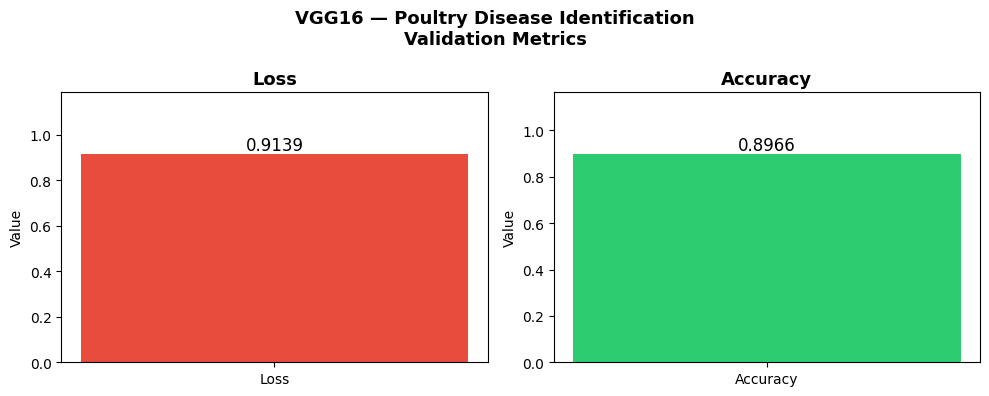

📊 Plot saved → artifacts/training/evaluation_metrics.png


In [21]:
import matplotlib.pyplot as plt
import json

# Re-run quick evaluation to get metrics
from cnnClassifier.config import ConfigurationManager
from cnnClassifier.components.model_evaluation_mlflow import Evaluation

config = ConfigurationManager()
val_config = config.get_validation_config()
evaluation = Evaluation(val_config)
evaluation._valid_generator()
model = evaluation.load_model(val_config.path_of_model)

# Evaluate on validation generator
score = model.evaluate(evaluation.valid_generator, verbose=1)

# Bar chart of final metrics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
metrics = ["Loss", "Accuracy"]
values  = [score[0], score[1]]
colors  = ["#e74c3c", "#2ecc71"]

for ax, m, v, c in zip(axes, metrics, values, colors):
    ax.bar([m], [v], color=c, width=0.4)
    ax.set_ylim(0, max(v * 1.3, 1.0))
    ax.set_title(m, fontsize=13, fontweight="bold")
    ax.text(0, v + 0.02, f"{v:.4f}", ha="center", fontsize=12)
    ax.set_ylabel("Value")

plt.suptitle("VGG16 — Poultry Disease Identification\nValidation Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/training/evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot saved → artifacts/training/evaluation_metrics.png")


## 1️⃣3️⃣  Prediction Demo on a Sample Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[0]


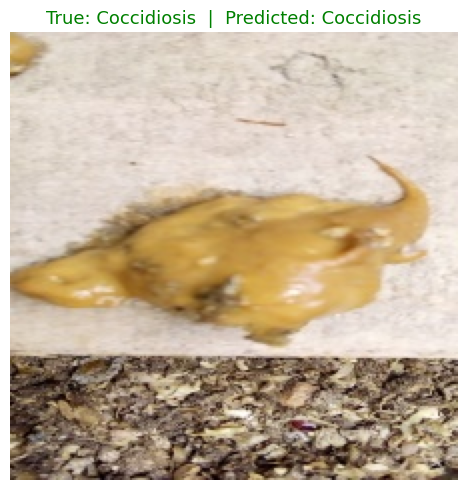


🔍 Prediction: Coccidiosis


In [22]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from cnnClassifier.pipeline.predict import PredictionPipeline

# Pick the first available image from any class
data_dir = "artifacts/data_ingestion/Chicken-fecal-images"
sample_img = None
for cls in os.listdir(data_dir):
    cls_dir = os.path.join(data_dir, cls)
    imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
    if imgs:
        sample_img = os.path.join(cls_dir, imgs[0])
        true_label = cls
        break

if sample_img:
    shutil.copy(sample_img, "inputImage.jpg")
    pipeline = PredictionPipeline("inputImage.jpg")
    result = pipeline.predict()
    pred_label = result[0]["image"]

    plt.figure(figsize=(5, 5))
    plt.imshow(mpimg.imread("inputImage.jpg"))
    plt.title(f"True: {true_label}  |  Predicted: {pred_label}", fontsize=13,
              color="green" if true_label.lower() in pred_label.lower() else "red")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("artifacts/training/sample_prediction.png", dpi=150)
    plt.show()
    print(f"\n🔍 Prediction: {pred_label}")
else:
    print("⚠️  No sample images found")


## 1️⃣4️⃣  Save All Files & Create Final ZIP

In [23]:
import os, shutil, zipfile
from google.colab import files

OUTPUT_ZIP = "/content/Poultry_Disease_Identification_Colab_Output.zip"

EXCLUDE_DIRS  = {".git", "__pycache__", ".dvc", "tensorboard_log_dir"}
EXCLUDE_EXTS  = {".pyc"}

def should_skip(path):
    parts = path.replace("\\", "/").split("/")
    return any(p in EXCLUDE_DIRS for p in parts)

project_root = os.getcwd()  # /content/poultry_disease_identification

print(f"📦 Zipping {project_root} …")
with zipfile.ZipFile(OUTPUT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, fnames in os.walk(project_root):
        # Prune excluded directories
        dirs[:] = [d for d in dirs if d not in EXCLUDE_DIRS]
        for fname in fnames:
            if os.path.splitext(fname)[1] in EXCLUDE_EXTS:
                continue
            full_path = os.path.join(root, fname)
            arc_name  = os.path.relpath(full_path, os.path.dirname(project_root))
            zf.write(full_path, arc_name)

size_mb = os.path.getsize(OUTPUT_ZIP) / (1024*1024)
print(f"\n✅ ZIP created: {OUTPUT_ZIP}  ({size_mb:.1f} MB)")
print("⬇️  Downloading …")
files.download(OUTPUT_ZIP)


📦 Zipping /content/poultry_disease_identification …

✅ ZIP created: /content/Poultry_Disease_Identification_Colab_Output.zip  (231.7 MB)
⬇️  Downloading …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>